# S&P 500 50/50 再平衡策略回測
## 兩種方式比較：500 支成分股（美元成交量代理）vs SPY 單一 ETF

**策略邏輯：**
- 本金一半放現金、一半投入 S&P 500
- 每天觀察 SPX 指數；若從上次再平衡後漲/跌超過 **±10%**，強制拉回 50/50
- 兩次再平衡之間，讓比例隨市場自然漂移（不每天交易）

| | 方式一 | 方式二 |
|--|--|--|
| **持有什麼** | ~500 支 S&P 500 成分股 | 1 支 SPY ETF |
| **市值加權** | 美元成交量代理（近似） | SPY 本身即真實市值加權 |
| **再平衡訊號** | SPX 指數（相同） | SPX 指數（相同） |
| **calc_stat 資料** | spx_data（500支個股） | spy_data（僅 SPY） |

> **為何需要個股資料才能計算回測？**  
> Quantiacs 的 `calc_stat()` 需要知道你每天「持有哪些股票、各漲跌多少」
> 才能算出你的實際 P&L 和滑價成本。SPX 指數只是一個數字，
> 沒有個別股票的 high/low/close，所以不能直接用指數計算回測。

## 環境設定：如何在 uv 下啟動 Jupyter

本專案使用 `uv` 管理 Python 環境。  
Jupyter 不在 `pyproject.toml` 的正式依賴中，用 `--with` 旗標臨時載入即可：

```bash
# Jupyter Notebook（傳統介面）
uv run --with jupyter jupyter notebook

# 或 JupyterLab（現代介面，推薦）
uv run --with jupyterlab jupyter lab
```

若想永久加入依賴（之後直接 `uv run jupyter notebook` 即可）：
```bash
uv add --dev jupyter
```

In [1]:
# ──────────────────────────────────────────────────────────────────
# 載入套件
# ──────────────────────────────────────────────────────────────────

# %matplotlib inline 告訴 Jupyter：matplotlib 的圖表直接顯示在 notebook 裡
# 不加這行的話圖表不會內嵌顯示（只能存到檔案）
%matplotlib inline

import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from dotenv import load_dotenv
load_dotenv()  # 從 .env 讀取 API_KEY，Quantiacs 連線需要

import qnt.data as qndata      # 資料載入
import qnt.stats as qnstats    # 回測統計計算
import qnt.output as qnout     # 輸出清理

print('套件載入完成')

NOTICE: The environment variable DATA_BASE_URL was not specified. The default value is 'https://data-api.quantiacs.io/'
NOTICE: The environment variable CACHE_RETENTION was not specified. The default value is '7'
NOTICE: The environment variable CACHE_DIR was not specified. The default value is 'data-cache'


套件載入完成


In [2]:
# ──────────────────────────────────────────────────────────────────
# 策略參數（兩種方式共用，確保比較的公平性）
# ──────────────────────────────────────────────────────────────────

START_DATE        = '2007-01-03'  # 回測起始日
THRESHOLD         = 0.10          # 再平衡閾值：SPX 漲/跌超過 10% 才觸發
TARGET_ALLOC      = 0.50          # 目標配置：50% 股票 + 50% 現金
CAP_WEIGHT_WINDOW = 63            # 計算美元成交量代理時的滾動天數（約 1 季）

# calc_stat 的固定參數
# slippage_factor=0.05：每筆交易滑價 = ATR × 5%（ATR = 近期日內價格波幅）
# per_asset=False：以整體組合計算統計（而非個別股票各自算）
# points_per_year=251：一年約 251 個交易日，用於年化計算
CALC_STAT_KWARGS = dict(
    slippage_factor = 0.05,
    min_periods     = 1,
    max_periods     = None,
    per_asset       = False,
    points_per_year = 251,
)

os.makedirs('results', exist_ok=True)

print(f'回測起始日  : {START_DATE}')
print(f'再平衡閾值  : ±{THRESHOLD:.0%}')
print(f'目標配置    : {TARGET_ALLOC:.0%} 股票 + {1-TARGET_ALLOC:.0%} 現金')

回測起始日  : 2007-01-03
再平衡閾值  : ±10%
目標配置    : 50% 股票 + 50% 現金


In [3]:
# ──────────────────────────────────────────────────────────────────
# 共用函式：計算每日「股票總配置比例」和「再平衡觸發旗標」
# 兩種方式（500 支個股 / SPY）都使用這個相同的邏輯
# ──────────────────────────────────────────────────────────────────

def compute_rebalance_weights(spx_prices, threshold=THRESHOLD, target=TARGET_ALLOC):
    """
    輸入 SPX 指數每日收盤價（numpy array），輸出：
      weights : 每天股票部位的總比例（float array，值在 0~1 之間）
      flags   : 每天是否觸發再平衡（bool array）

    兩次再平衡之間的「漂移公式」推導：
      假設上次再平衡後，股票部位 = target，現金部位 = (1 - target)
      股票部位的價值隨 SPX 乘以 r = spx[t] / spx[上次再平衡]，現金不變
      → 新的股票佔比 = target*r / (target*r + (1-target))
    """
    n = len(spx_prices)
    weights = np.zeros(n)
    flags   = np.zeros(n, dtype=bool)
    last_p  = spx_prices[0]   # 記錄上次再平衡時的 SPX 價格

    for i in range(n):
        p = spx_prices[i]
        if np.isnan(p) or p <= 0:
            # 資料缺漏：維持前一天的配置
            weights[i] = weights[i-1] if i > 0 else target
            continue

        r = p / last_p   # 相對於上次再平衡的漲跌倍數

        if abs(r - 1.0) >= threshold:
            # 觸發再平衡：強制拉回目標配置，重設基準價格
            weights[i] = target
            flags[i]   = True
            last_p     = p
        else:
            # 未觸發：讓配置自然漂移（不交易）
            weights[i] = (target * r) / (target * r + (1.0 - target))

    return weights, flags

print('compute_rebalance_weights() 定義完成')
print('  輸入：SPX 每日收盤價 (numpy array)')
print('  輸出：(total_weights, rebal_flags)')
print('        total_weights = 每日股票配置比例（接近 0.5，再平衡當天正好 = 0.5）')
print('        rebal_flags   = 再平衡觸發日旗標（True/False）')

compute_rebalance_weights() 定義完成
  輸入：SPX 每日收盤價 (numpy array)
  輸出：(total_weights, rebal_flags)
        total_weights = 每日股票配置比例（接近 0.5，再平衡當天正好 = 0.5）
        rebal_flags   = 再平衡觸發日旗標（True/False）


---
# 方式一：500 支 S&P 500 成分股（美元成交量代理市值加權）

## 概念
「持有 S&P 500」= 同時持有全部 ~500 支成分股，並按各自市值比例分配資金。

因 Quantiacs 沒有直接的市值資料，用 **63 天滾動平均美元成交量（close × vol）**
作為市值的代理指標。市值大的公司日均成交量也大，兩者高度相關。

## 資料流
```
spx_data（500支個股）
  ├─ close × vol → rolling mean → 除以總和 → cap_weights（每股佔比）
  └─ 傳給 calc_stat()，計算每股實際報酬和滑價

spx_index（指數）
  └─ compute_rebalance_weights() → total_weights（股票總配置比例）

output[t, i] = total_weights[t] × cap_weights[t, i]
             = 第 t 天，第 i 支股票的持倉比例
```

In [4]:
# ──────────────────────────────────────────────────────────────────
# 方式一 — 步驟 1：載入 S&P 500 成分股個股資料
# ──────────────────────────────────────────────────────────────────

# stocks_load_spx_data() 載入所有 S&P 500 成分股（約 500~800 支，視年份而定）
# 回傳的是 3D DataArray，維度為 (time, asset, field)
#   field 包含：open / high / low / close / vol / is_liquid / divs / split ...
#   is_liquid：Quantiacs 標記該股當天是否有足夠流動性可以交易
#
# 這份資料之後有兩個用途：
#   1. 計算市值代理權重（用 close 和 vol）
#   2. 傳給 calc_stat()，計算你的實際 P&L 和滑價（用 close / high / low）
print('載入 S&P 500 成分股資料中（需要幾分鐘）...')
spx_data = qndata.stocks_load_spx_data(min_date=START_DATE, forward_order=True)

print(f'\n資料形狀  : {dict(zip(spx_data.dims, spx_data.shape))}')
print(f'時間範圍  : {str(spx_data.time.values[0])[:10]} ~ {str(spx_data.time.values[-1])[:10]}')
print(f'股票數量  : {len(spx_data.asset)} 支')
print(f'資料欄位  : {list(spx_data.field.values)}')

# 預覽：前 3 天、前 5 支股票的收盤價
# （NaN 表示該股票在該時期尚未納入 S&P 500，或資料缺失）
print('\n--- 收盤價預覽（前 3 天 × 前 5 支股票）---')
display(spx_data.sel(field='close').isel(time=slice(0, 3), asset=slice(0, 5)).to_pandas())

載入 S&P 500 成分股資料中（需要幾分鐘）...
fetched chunk 1/21 0s
fetched chunk 2/21 0s
fetched chunk 3/21 0s
fetched chunk 4/21 0s
fetched chunk 5/21 0s
fetched chunk 6/21 1s
fetched chunk 7/21 1s
fetched chunk 8/21 1s
fetched chunk 9/21 1s
fetched chunk 10/21 1s
fetched chunk 11/21 1s
fetched chunk 12/21 1s
fetched chunk 13/21 1s
fetched chunk 14/21 1s
fetched chunk 15/21 1s
fetched chunk 16/21 1s
fetched chunk 17/21 2s
fetched chunk 18/21 2s
fetched chunk 19/21 2s
fetched chunk 20/21 2s
fetched chunk 21/21 2s
Data loaded 3s

資料形狀  : {'field': 8, 'time': 4862, 'asset': 844}
時間範圍  : 2007-01-03 ~ 2026-04-30
股票數量  : 844 支
資料欄位  : ['open', 'low', 'high', 'close', 'vol', 'divs', 'split_cumprod', 'is_liquid']

--- 收盤價預覽（前 3 天 × 前 5 支股票）---


asset,NAS:AAL,NAS:AAPL,NAS:ABI,NAS:ABKFQ,NAS:ABNB
time,,,,,
2007-01-03,NaN,2.9929,NaN,89.82,NaN
2007-01-04,NaN,3.0593,NaN,89.43,NaN
2007-01-05,NaN,3.0375,NaN,88.14,NaN


In [5]:
# ──────────────────────────────────────────────────────────────────
# 方式一 — 步驟 2：載入 SPX 指數（作為再平衡訊號）
# ──────────────────────────────────────────────────────────────────

# index_load_data() 載入市場指數的每日收盤價
# assets=['SPX'] 指定 S&P 500 指數
#
# 注意：這裡的資料只是「每天一個數字」（指數價格），沒有個股 OHLCV
# 它的唯一作用是告訴我們「市場今天漲了多少」，用來判斷是否觸發再平衡
print('載入 SPX 指數資料...')
spx_index = qndata.index_load_data(assets=['SPX'], min_date=START_DATE, forward_order=True)

# .sel(asset='SPX')：從 DataArray 中取出 SPX 這個資產（消除 asset 維度）
# .reindex(time=spx_data.time, method='ffill')：
#   把指數的日期對齊到 spx_data 的日期
#   method='ffill'（前向填充）：若某天指數沒有資料，沿用前一天的值
#   這是必要的，因為 spx_data 和 spx_index 的交易日不一定完全相同
spx_prices = (
    spx_index.sel(asset='SPX')
    .reindex(time=spx_data.time, method='ffill')
    .values   # 轉成 numpy array，形狀：(N,)，N = 交易日數
)

print(f'指數資料點數：{len(spx_prices)} 天')

# 製成 DataFrame 方便查看
spx_series = pd.Series(spx_prices, index=pd.to_datetime(spx_data.time.values), name='SPX 收盤價')
print('\n--- SPX 指數收盤價預覽（前 10 天）---')
display(spx_series.head(10).to_frame())

載入 SPX 指數資料...
指數資料點數：4862 天

--- SPX 指數收盤價預覽（前 10 天）---


,SPX 收盤價
2007-01-03,1416.60
2007-01-04,1418.34
2007-01-05,1409.71
2007-01-08,1412.84
2007-01-09,1412.11
2007-01-10,1414.85
2007-01-11,1423.82
2007-01-12,1430.73
2007-01-16,1431.90
2007-01-17,1430.62


In [6]:
# ──────────────────────────────────────────────────────────────────
# 方式一 — 步驟 3：計算每支股票的「市值代理權重」(cap_weights)
# ──────────────────────────────────────────────────────────────────

# 目標：算出「50% 的資金要如何分配給 500 支股票」
# 真實 S&P 500 是市值加權（Apple ~7%、Microsoft ~6%...）
# 但 Quantiacs 沒有直接的市值資料，所以用美元成交量作代理：
#   dollar_vol = close × vol（= 每天這支股票的總成交金額）
#   市值大的公司日均成交量也大 → 兩者高度正相關 → 合理的近似

close     = spx_data.sel(field='close')
vol       = spx_data.sel(field='vol')
is_liquid = spx_data.sel(field='is_liquid')

# 只對流動性足夠（is_liquid == 1）的股票計算，非流動股票設為 NaN
# 這樣可以避免把資金分配到「今天無法實際交易」的股票
dollar_vol = (close * vol).where(is_liquid == 1)

# 63 天滾動平均：平滑每日的波動，避免某天大量交易造成單日異常高的比重
# min_periods=1：即使歷史資料不足 63 天，也用現有天數計算（期初不跳過）
dollar_vol_smooth = dollar_vol.rolling(time=CAP_WEIGHT_WINDOW, min_periods=1).mean()

# 每天除以所有股票的加總 → 得到「佔比」（加總為 1.0）
cap_weights = dollar_vol_smooth / dollar_vol_smooth.sum(dim='asset')
cap_weights = cap_weights.fillna(0.0)  # NaN（非流動股）填 0（不持有）

print(f'cap_weights 形狀：{dict(zip(cap_weights.dims, cap_weights.shape))}')
print(f'（每天每支股票一個值，代表「若持有 100% 股票，這支佔多少比例」）')

# 預覽：某一天（第 500 天）的個股權重 top 10
day_idx = 500
day_label = str(spx_data.time.values[day_idx])[:10]
day_weights = (
    cap_weights.isel(time=day_idx)
    .to_pandas()
    .sort_values(ascending=False)
    .head(10)
    .to_frame('cap_weight')
)
day_weights['pct'] = day_weights['cap_weight'].map('{:.4%}'.format)
print(f'\n--- {day_label}（第 {day_idx} 天）個股市值代理權重 Top 10 ---')
display(day_weights)

total_check = cap_weights.isel(time=day_idx).values.sum()
print(f'\n所有股票權重加總（應 ≈ 1.0）：{total_check:.6f}')

cap_weights 形狀：{'time': 4862, 'asset': 844}
（每天每支股票一個值，代表「若持有 100% 股票，這支佔多少比例」）

--- 2008-12-26（第 500 天）個股市值代理權重 Top 10 ---


,cap_weight,pct
asset,,
NAS:AAPL,0.044206,4.4206%
NYS:XOM,0.037985,3.7985%
NAS:GOOGL,0.023091,2.3091%
NYS:JPM,0.022277,2.2277%
NYS:BAC,0.021719,2.1719%
NAS:MSFT,0.020734,2.0734%
NYS:GS,0.020670,2.0670%
NYS:WFC,0.019520,1.9520%
NYS:C,0.019240,1.9240%



所有股票權重加總（應 ≈ 1.0）：1.000000


In [7]:
# ──────────────────────────────────────────────────────────────────
# 方式一 — 步驟 4：計算每天的「股票總配置比例」和「再平衡觸發旗標」
# ──────────────────────────────────────────────────────────────────

# 這裡呼叫前面定義的共用函式
# 輸入 spx_prices（SPX 每日收盤價），輸出：
#   total_weights : 每天要投入股票的總比例（0 ~ 1）
#                   在再平衡日精確等於 TARGET_ALLOC（0.5）
#                   其他天在 0.5 附近漂移
#   rebal_flags   : True = 當天觸發再平衡
total_weights, rebal_flags = compute_rebalance_weights(spx_prices)

# 製成 DataFrame 方便查看
idx = pd.to_datetime(spx_data.time.values)
preview_df = pd.DataFrame({
    'SPX 收盤價' : spx_prices,
    '股票配置比例': total_weights,
    '再平衡觸發' : rebal_flags,
}, index=idx)

print(f'總再平衡次數：{rebal_flags.sum()} 次')
print(f'平均配置比例：{total_weights.mean():.4f}（目標 {TARGET_ALLOC}）')

print('\n--- 前 30 天預覽 ---')
display(preview_df.head(30))

print('\n--- 前 10 次再平衡觸發日 ---')
display(preview_df[preview_df['再平衡觸發']].head(10))

總再平衡次數：52 次
平均配置比例：0.5050（目標 0.5）

--- 前 30 天預覽 ---


,SPX 收盤價,股票配置比例,再平衡觸發
2007-01-03,1416.60,0.500000,False
2007-01-04,1418.34,0.500307,False
2007-01-05,1409.71,0.498781,False
2007-01-08,1412.84,0.499336,False
2007-01-09,1412.11,0.499206,False
2007-01-10,1414.85,0.499691,False
2007-01-11,1423.82,0.501271,False
2007-01-12,1430.73,0.502481,False
2007-01-16,1431.90,0.502686,False
2007-01-17,1430.62,0.502462,False



--- 前 10 次再平衡觸發日 ---


,SPX 收盤價,股票配置比例,再平衡觸發
2007-10-09,1565.15,0.5,True
2007-11-26,1407.22,0.5,True
2008-07-02,1261.52,0.5,True
2008-10-02,1114.28,0.5,True
2008-10-07,996.23,0.5,True
2008-10-24,876.77,0.5,True
2008-10-31,968.75,0.5,True
2008-11-12,852.30,0.5,True
2008-11-20,752.44,0.5,True
2008-11-24,851.81,0.5,True


In [8]:
# ──────────────────────────────────────────────────────────────────
# 方式一 — 步驟 5：建立 Quantiacs 格式的組合權重輸出
# ──────────────────────────────────────────────────────────────────

# Quantiacs 需要的 output 格式：
#   DataArray，維度為 (time, asset)
#   output[t, i] = 第 t 天，第 i 支股票的持倉比例
#   所有股票加總 = 投入股票的總比例（其餘自動視為現金）
#
# 計算公式（兩層乘法）：
#   output[t, i] = total_weights[t]  × cap_weights[t, i]
#                = 「今天股票總比例」 × 「這支股票在股票部位中的佔比」
#
# 例：total_weights[t] = 0.5，Apple 的 cap_weight = 0.065
#   → output[t, AAPL] = 0.5 × 0.065 = 0.0325（Apple 佔整個組合 3.25%）

cap_np  = cap_weights.values           # shape: (time, asset)
tw_col  = total_weights[:, np.newaxis] # shape: (time, 1)，增加一維方便廣播
out_np  = tw_col * cap_np              # shape: (time, asset)，廣播乘法

# 包裝成 xr.DataArray，座標對齊 spx_data（才能正確傳給 calc_stat）
output_s1 = xr.DataArray(out_np, dims=close.dims, coords=close.coords)

print(f'output 形狀：{dict(zip(output_s1.dims, output_s1.shape))}')

# 預覽某一天的個股持倉比例（應等於 total_weights × cap_weights）
day_idx = 500
day_label = str(spx_data.time.values[day_idx])[:10]
day_output = (
    output_s1.isel(time=day_idx)
    .to_pandas()
    .sort_values(ascending=False)
    .head(10)
    .to_frame('weight')
)
day_output['pct'] = day_output['weight'].map('{:.4%}'.format)
print(f'\n--- {day_label} 個股持倉比例 Top 10 ---')
display(day_output)

# 驗證：所有股票加總應等於 total_weights[day_idx]
output_sum = output_s1.isel(time=day_idx).values.sum()
print(f'\n當天所有股票比例加總     : {output_sum:.6f}')
print(f'total_weights[{day_idx}]     : {total_weights[day_idx]:.6f}')
print(f'差值（應接近 0）         : {output_sum - total_weights[day_idx]:.2e}')
print(f'（剩下的 {1 - output_sum:.4f} 為現金，由 Quantiacs 自動處理）')

output 形狀：{'time': 4862, 'asset': 844}

--- 2008-12-26 個股持倉比例 Top 10 ---


,weight,pct
asset,,
NAS:AAPL,0.022372,2.2372%
NYS:XOM,0.019224,1.9224%
NAS:GOOGL,0.011686,1.1686%
NYS:JPM,0.011274,1.1274%
NYS:BAC,0.010992,1.0992%
NAS:MSFT,0.010493,1.0493%
NYS:GS,0.010461,1.0461%
NYS:WFC,0.009879,0.9879%
NYS:C,0.009737,0.9737%



當天所有股票比例加總     : 0.506085
total_weights[500]     : 0.506085
差值（應接近 0）         : 0.00e+00
（剩下的 0.4939 為現金，由 Quantiacs 自動處理）


In [9]:
# ──────────────────────────────────────────────────────────────────
# 方式一 — 步驟 6：計算回測績效統計
# ──────────────────────────────────────────────────────────────────

# qnout.clean()：Quantiacs 內建清理函式
#   - 過濾掉 is_liquid == 0 的持倉（不能持有當天無法交易的股票）
#   - 處理缺漏日期、資料異常等問題
#   → Quantiacs 規定在計算統計前必須先執行 clean()
output_clean_s1 = qnout.clean(output_s1, spx_data)

# qnstats.calc_stat()：計算組合績效統計
#
# 第一個參數 spx_data：個股的 OHLCV 資料
#   → 用 close[t, i] / close[t-1, i] 計算每支股票每天的報酬率
#   → 用 high[t, i] - low[t, i] 計算 ATR，再乘以滑價係數算出交易成本
#   ★ 這就是為什麼必須用個股資料，不能用 spx_index：
#     個股資料有 500 支各自的 close/high/low，指數只是一個數字
#
# 第二個參數 output_clean_s1：持倉權重
#   → 告訴系統「每天持有哪些股票、各多少比例」
#
# .sel(time=slice(START_DATE, None))：只計算 START_DATE 之後的統計
stats_s1 = qnstats.calc_stat(
    spx_data,
    output_clean_s1.sel(time=slice(START_DATE, None)),
    **CALC_STAT_KWARGS,
)

print('=== 方式一：500 支成分股（美元成交量代理）===')
print('完整統計表（最後 5 行）：')
display(stats_s1.to_pandas().tail())

# 取最後一行 = 全期累積結果
last_s1  = stats_s1.to_pandas().iloc[-1]
equity_s1 = stats_s1.to_pandas()['equity']
total_ret_s1 = equity_s1.iloc[-1] / equity_s1.iloc[0] - 1

print('\n--- 主要績效指標 ---')
print(f'  Sharpe Ratio  : {last_s1["sharpe_ratio"]:.4f}')
print(f'  Annual Return : {last_s1["mean_return"]:.2%}')
print(f'  Volatility    : {last_s1["volatility"]:.2%}')
print(f'  Max Drawdown  : {last_s1["max_drawdown"]:.2%}')
print(f'  Avg Turnover  : {last_s1["avg_turnover"]:.2%}')
print(f'  Total Return  : {total_ret_s1:.2%}')
print(f'  再平衡次數    : {rebal_flags.sum()} 次')

Output cleaning...
Fix unique timestamps
Forward filling missing prices...
Check liquidity...
WARNING! Strategy trades non-liquid assets.
Applying liquidity filter...
Ok.
Check for missed dates...
Ok.
Normalize and cut big positions for index strategies (nasdaq100, s&p500)...
Final normalization...
Output cleaning complete.
=== 方式一：500 支成分股（美元成交量代理）===
完整統計表（最後 5 行）：


field,equity,relative_return,volatility,underwater,max_drawdown,sharpe_ratio,mean_return,bias,instruments,avg_turnover,avg_holding_time
time,,,,,,,,,,,
2026-04-24,3.243483,0.006910,0.113276,0.000000,-0.355419,0.553343,0.062680,1.0,786.0,0.009825,136.322443
2026-04-27,3.250320,0.002108,0.113265,0.000000,-0.355419,0.554300,0.062783,1.0,786.0,0.009825,136.327013
2026-04-28,3.233158,-0.005280,0.113260,-0.005280,-0.355419,0.551640,0.062479,1.0,786.0,0.009825,136.335077
2026-04-29,3.236811,0.001130,0.113249,-0.004156,-0.355419,0.552126,0.062527,1.0,786.0,0.009825,136.349210
2026-04-30,3.256774,0.006168,0.113245,0.000000,-0.355419,0.555005,0.062851,1.0,786.0,0.009825,139.622208



--- 主要績效指標 ---
  Sharpe Ratio  : 0.5550
  Annual Return : 6.29%
  Volatility    : 11.32%
  Max Drawdown  : -35.54%
  Avg Turnover  : 0.98%
  Total Return  : 225.68%
  再平衡次數    : 52 次


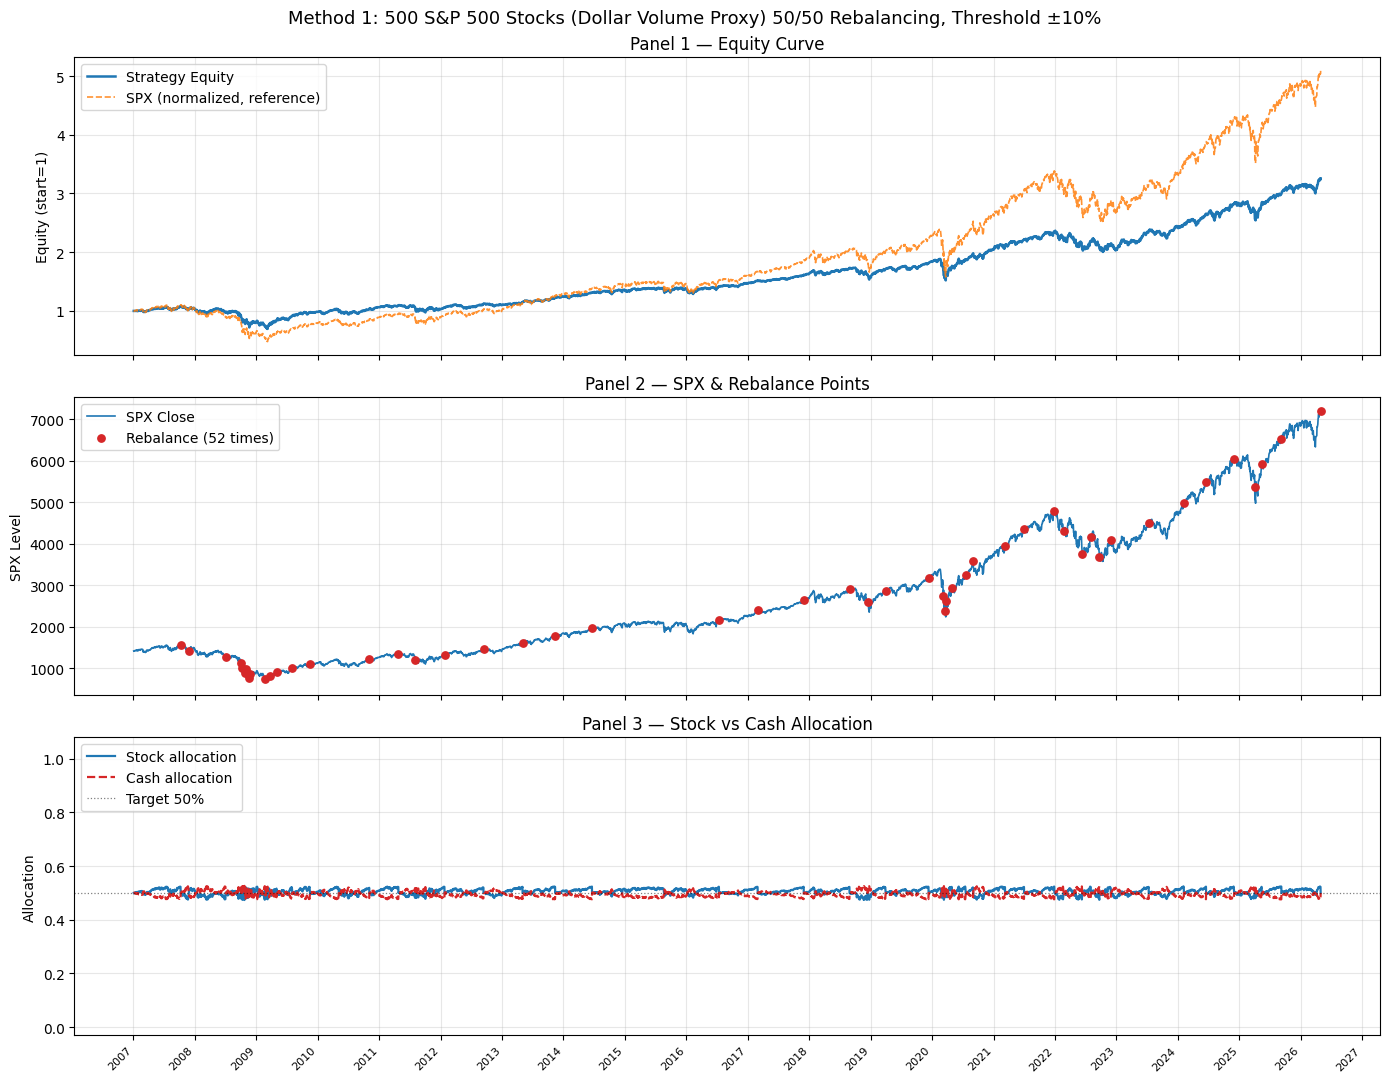

圖表已儲存至 results/s1_500stocks_chart.png


In [10]:
# ──────────────────────────────────────────────────────────────────
# 方式一 — 步驟 7：繪製回測圖表
# ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle("Method 1: 500 S&P 500 Stocks (Dollar Volume Proxy) 50/50 Rebalancing, Threshold ±10%", fontsize=13)

df_s1  = stats_s1.to_pandas()
times  = pd.to_datetime(spx_data.time.values)
spx_norm = pd.Series(spx_prices, index=times) / spx_prices[0]  # 標準化到起點 = 1

# Panel 1：淨值曲線 vs SPX（兩者都從 1 開始，方便比較）
ax1 = axes[0]
equity = df_s1['equity'].dropna()
ax1.plot(equity.index, equity.values, color='#1f77b4', linewidth=1.8, label='Strategy Equity')
ax1.plot(spx_norm.index, spx_norm.values, color='#ff7f0e', linewidth=1.2,
         linestyle='--', alpha=0.85, label='SPX (normalized, reference)')
ax1.set_ylabel('Equity (start=1)')
ax1.set_title('Panel 1 — Equity Curve')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Panel 2：SPX 走勢 + 再平衡觸發點（紅點）
ax2 = axes[1]
ax2.plot(times, spx_prices, color='#1f77b4', linewidth=1.2, label='SPX Close')
if rebal_flags.sum() > 0:
    rb_dates  = times[rebal_flags]
    rb_prices = pd.Series(spx_prices, index=times).reindex(rb_dates, method='nearest')
    ax2.scatter(rb_prices.index, rb_prices.values, color='#d62728', s=28, zorder=5,
                label=f'Rebalance ({rebal_flags.sum()} times)')
ax2.set_ylabel('SPX Level')
ax2.set_title('Panel 2 — SPX & Rebalance Points')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# Panel 3：股票 vs 現金配置比例
# total_weights = 股票配置，1 - total_weights = 現金配置
ax3 = axes[2]
tw_series_plot = pd.Series(total_weights, index=times)
ax3.plot(tw_series_plot.index, tw_series_plot.values,
         color='#1f77b4', linewidth=1.6, label='Stock allocation')
ax3.plot(tw_series_plot.index, 1 - tw_series_plot.values,
         color='#d62728', linewidth=1.6, linestyle='--', label='Cash allocation')
ax3.axhline(TARGET_ALLOC, color='black', linestyle=':', linewidth=0.9, alpha=0.5,
            label=f'Target {TARGET_ALLOC:.0%}')
ax3.set_ylim(-0.03, 1.08)
ax3.set_ylabel('Allocation')
ax3.set_title('Panel 3 — Stock vs Cash Allocation')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(axes[-1].get_xticklabels(), rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('results/s1_500stocks_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('圖表已儲存至 results/s1_500stocks_chart.png')

---
# 方式二：SPY 單一 ETF（yfinance 資料）

## 概念
SPY（SPDR S&P 500 ETF）是追蹤 S&P 500 指數的 ETF，本身就是真實市值加權。

## 為何不用 Quantiacs 模組？
Quantiacs 的資料庫沒有 SPY ETF 資料（`stocks_load_data(assets=['SPY'])` 回傳 time: 0）。
即使從其他來源取得 SPY OHLCV，`qnout.clean()` 和 `qnstats.calc_stat()` 也需要
`is_liquid`、`split_cumprod`、`divs` 等 Quantiacs 專屬欄位，因此改用 **yfinance**
搭配純 pandas/numpy 自訂回測，完整重現相同的策略邏輯與績效計算。

## 與方式一的差異

| | 方式一（500 支個股）| 方式二（SPY）|
|--|--|--|
| 持有的股票 | ~500 支成分股 | 1 支 SPY |
| 市值加權 | 美元成交量代理（近似）| SPY 本身即真實市值加權 |
| 每次再平衡交易量 | ~500 筆 | 1 筆 |
| 滑價成本 | 各股各算 ATR | SPY ATR × slippage_factor |
| 再平衡訊號 | SPX 指數（相同）| ^GSPC 指數（同等）|
| 回測框架 | Quantiacs calc_stat | 自訂 pandas/numpy |

## 資料流
```
yfinance: SPY OHLCV
  └─ 計算每日持倉報酬 + ATR 滑價 → 累積淨值

yfinance: ^GSPC（S&P 500 指數）
  └─ compute_rebalance_weights() → total_weights

output[t] = total_weights[t]   ← 只有一支 SPY，無需分配個股比例
```

In [11]:
# ──────────────────────────────────────────────────────────────────
# 方式二 — 步驟 1：透過 yfinance 載入 SPY 與 ^GSPC 資料
# ──────────────────────────────────────────────────────────────────
# Quantiacs stocks_load_data(assets=['SPY']) 回傳空資料（time: 0），
# 平台資料庫不含 ETF。改用 yfinance，auto_adjust=True 自動處理股票分割/股息。

import yfinance as yf

print('透過 yfinance 載入 SPY 與 ^GSPC 資料中...')
spy_yf = yf.download('SPY',   start=START_DATE, progress=False, auto_adjust=True)
spx_yf = yf.download('^GSPC', start=START_DATE, progress=False, auto_adjust=True)

# 取兩者共同的交易日（SPY 和 ^GSPC 交易日幾乎相同，以交集確保對齊）
common_dates_s2 = spy_yf.index.intersection(spx_yf.index)

spy_close_s2 = spy_yf['Close'].reindex(common_dates_s2).values.flatten()
spy_high_s2  = spy_yf['High'].reindex(common_dates_s2).values.flatten()
spy_low_s2   = spy_yf['Low'].reindex(common_dates_s2).values.flatten()
spx_prices_s2 = (
    spx_yf['Close']
    .reindex(common_dates_s2, method='ffill')
    .values.flatten()
)

print(f'\n交易日數   : {len(common_dates_s2)} 天')
print(f'時間範圍   : {str(common_dates_s2[0])[:10]} ~ {str(common_dates_s2[-1])[:10]}')
print(f'SPY 收盤   : {spy_close_s2[0]:.2f} ~ {spy_close_s2[-1]:.2f}')
print(f'SPX 指數   : {spx_prices_s2[0]:.2f} ~ {spx_prices_s2[-1]:.2f}')

print('\n--- SPY 收盤價預覽（前 10 天）---')
display(pd.DataFrame({'SPY Close': spy_close_s2[:10]}, index=common_dates_s2[:10]))

透過 yfinance 載入 SPY 與 ^GSPC 資料中...

交易日數   : 4864 天
時間範圍   : 2007-01-03 ~ 2026-05-04
SPY 收盤   : 99.12 ~ 718.01
SPX 指數   : 1416.60 ~ 7200.75

--- SPY 收盤價預覽（前 10 天）---


,SPY Close
Date,
2007-01-03,99.124184
2007-01-04,99.334549
2007-01-05,98.542236
2007-01-08,98.997993
2007-01-09,98.913857
2007-01-10,99.243416
2007-01-11,99.678131
2007-01-12,100.435387
2007-01-16,100.239082


In [12]:
# ──────────────────────────────────────────────────────────────────
# 方式二 — 步驟 2：計算每天的「股票總配置比例」和「再平衡觸發旗標」
# ──────────────────────────────────────────────────────────────────
# 與方式一完全相同的邏輯，共用 compute_rebalance_weights()；
# 差別只是這裡的 SPX 訊號來自 yfinance ^GSPC（對齊到 SPY 交易日）

total_weights_s2, rebal_flags_s2 = compute_rebalance_weights(spx_prices_s2)

preview_s2 = pd.DataFrame({
    'SPX 收盤價' : spx_prices_s2,
    '股票配置比例': total_weights_s2,
    '再平衡觸發' : rebal_flags_s2,
}, index=common_dates_s2)

print(f'總再平衡次數：{rebal_flags_s2.sum()} 次')
print(f'平均配置比例：{total_weights_s2.mean():.4f}（目標 {TARGET_ALLOC}）')

print('\n--- 前 30 天預覽 ---')
display(preview_s2.head(30))

print('\n--- 前 10 次再平衡觸發日 ---')
display(preview_s2[preview_s2['再平衡觸發']].head(10))

總再平衡次數：51 次
平均配置比例：0.5049（目標 0.5）

--- 前 30 天預覽 ---


,SPX 收盤價,股票配置比例,再平衡觸發
Date,,,
2007-01-03,1416.599976,0.500000,False
2007-01-04,1418.339966,0.500307,False
2007-01-05,1409.709961,0.498781,False
2007-01-08,1412.839966,0.499336,False
2007-01-09,1412.109985,0.499206,False
2007-01-10,1414.849976,0.499691,False
2007-01-11,1423.819946,0.501271,False
2007-01-12,1430.729980,0.502481,False
2007-01-16,1431.900024,0.502686,False



--- 前 10 次再平衡觸發日 ---


,SPX 收盤價,股票配置比例,再平衡觸發
Date,,,
2007-10-09,1565.150024,0.5,True
2007-11-26,1407.219971,0.5,True
2008-07-02,1261.520020,0.5,True
2008-09-29,1106.420044,0.5,True
2008-10-08,984.940002,0.5,True
2008-10-24,876.770020,0.5,True
2008-10-31,968.750000,0.5,True
2008-11-12,852.299988,0.5,True
2008-11-20,752.440002,0.5,True


In [13]:
# ──────────────────────────────────────────────────────────────────
# 方式二 — 步驟 3：計算每日投資組合報酬（含 ATR 滑價）
# ──────────────────────────────────────────────────────────────────
# 對齊 Quantiacs 的 calc_stat 滑價公式：
#   slippage[t] = |Δweight[t]| × (high[t]-low[t])/close[t] × slippage_factor
#
# 持倉報酬公式（昨天的倉位乘以今天的漲跌）：
#   daily_ret[t] = weight[t-1] × (close[t]/close[t-1] - 1) - slippage[t]

SLIPPAGE_FACTOR = CALC_STAT_KWARGS['slippage_factor']   # 0.05

# 每日 SPY 報酬率（第 0 天設為 0，沒有前一天可參考）
spy_ret = np.zeros(len(spy_close_s2))
spy_ret[1:] = spy_close_s2[1:] / spy_close_s2[:-1] - 1

# ATR 比例（日內振幅 / 收盤價），過濾 NaN 與零價
atr_pct = np.where(
    (spy_close_s2 > 0) & ~np.isnan(spy_close_s2),
    (spy_high_s2 - spy_low_s2) / spy_close_s2,
    0.0,
)

# 換手率：起始前假設持倉為 0（第一天買入算一次滑價）
weights_prev = np.concatenate([[0.0], total_weights_s2[:-1]])
turnover_s2  = np.abs(total_weights_s2 - weights_prev)
slippage_s2  = turnover_s2 * atr_pct * SLIPPAGE_FACTOR

# 每日組合報酬 = 昨天持倉 × 今天 SPY 報酬 - 今天滑價
daily_port_ret_s2 = weights_prev * spy_ret - slippage_s2

# 累積淨值（從 1 開始）
equity_s2 = pd.Series(
    np.cumprod(1 + daily_port_ret_s2),
    index=common_dates_s2,
    name='equity',
)

print(f'每日報酬計算完成')
print(f'淨值範圍：{equity_s2.min():.4f} ~ {equity_s2.max():.4f}')
print(f'最終淨值：{equity_s2.iloc[-1]:.4f}')

每日報酬計算完成
淨值範圍：0.7214 ~ 2.8795
最終淨值：2.8740


In [14]:
# ──────────────────────────────────────────────────────────────────
# 方式二 — 步驟 4：計算回測績效統計（對齊 Quantiacs calc_stat 輸出格式）
# ──────────────────────────────────────────────────────────────────
POINTS_PER_YEAR = CALC_STAT_KWARGS['points_per_year']   # 251

port_ret_series = pd.Series(daily_port_ret_s2, index=common_dates_s2)

mean_daily   = port_ret_series.mean()
std_daily    = port_ret_series.std()
sharpe_s2    = (mean_daily / std_daily) * np.sqrt(POINTS_PER_YEAR) if std_daily > 0 else 0.0
mean_ret_s2  = mean_daily * POINTS_PER_YEAR
vol_s2       = std_daily  * np.sqrt(POINTS_PER_YEAR)

rolling_max  = equity_s2.cummax()
underwater_s2 = equity_s2 / rolling_max - 1
max_dd_s2    = underwater_s2.min()

total_ret_s2    = equity_s2.iloc[-1] / equity_s2.iloc[0] - 1
avg_turnover_s2 = turnover_s2.mean()

print('=== 方式二：SPY 單一 ETF（yfinance）===')
print(f'\n--- 主要績效指標 ---')
print(f'  Sharpe Ratio  : {sharpe_s2:.4f}')
print(f'  Annual Return : {mean_ret_s2:.2%}')
print(f'  Volatility    : {vol_s2:.2%}')
print(f'  Max Drawdown  : {max_dd_s2:.2%}')
print(f'  Avg Turnover  : {avg_turnover_s2:.2%}')
print(f'  Total Return  : {total_ret_s2:.2%}')
print(f'  再平衡次數    : {rebal_flags_s2.sum()} 次')

=== 方式二：SPY 單一 ETF（yfinance）===

--- 主要績效指標 ---
  Sharpe Ratio  : 0.6056
  Annual Return : 5.93%
  Volatility    : 9.79%
  Max Drawdown  : -31.93%
  Avg Turnover  : 0.23%
  Total Return  : 187.51%
  再平衡次數    : 51 次


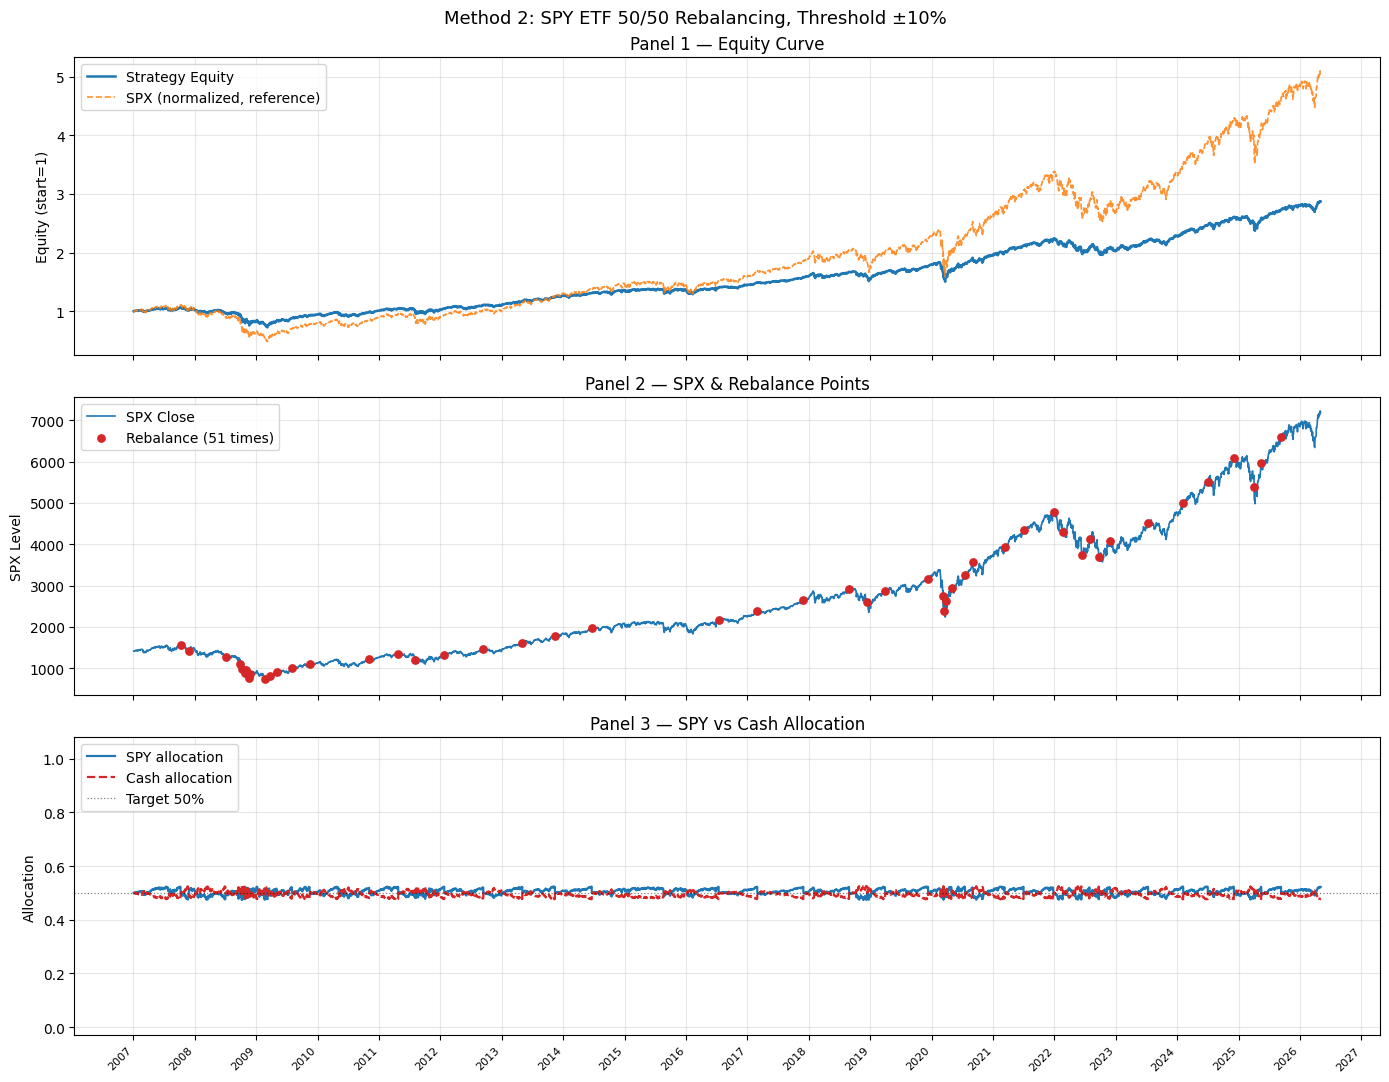

圖表已儲存至 results/s2_spy_chart.png


In [15]:
# ──────────────────────────────────────────────────────────────────
# 方式二 — 步驟 5：繪製回測圖表
# ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle("Method 2: SPY ETF 50/50 Rebalancing, Threshold ±10%", fontsize=13)

spx_norm_s2 = pd.Series(spx_prices_s2, index=common_dates_s2) / spx_prices_s2[0]

ax1 = axes[0]
ax1.plot(equity_s2.index, equity_s2.values, color='#1f77b4', linewidth=1.8, label='Strategy Equity')
ax1.plot(spx_norm_s2.index, spx_norm_s2.values, color='#ff7f0e', linewidth=1.2,
         linestyle='--', alpha=0.85, label='SPX (normalized, reference)')
ax1.set_ylabel('Equity (start=1)')
ax1.set_title('Panel 1 — Equity Curve')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(common_dates_s2, spx_prices_s2, color='#1f77b4', linewidth=1.2, label='SPX Close')
if rebal_flags_s2.sum() > 0:
    rb_dates_s2  = common_dates_s2[rebal_flags_s2]
    rb_prices_s2 = pd.Series(spx_prices_s2, index=common_dates_s2).reindex(rb_dates_s2, method='nearest')
    ax2.scatter(rb_prices_s2.index, rb_prices_s2.values, color='#d62728', s=28, zorder=5,
                label=f'Rebalance ({rebal_flags_s2.sum()} times)')
ax2.set_ylabel('SPX Level')
ax2.set_title('Panel 2 — SPX & Rebalance Points')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
tw_s2_plot = pd.Series(total_weights_s2, index=common_dates_s2)
ax3.plot(tw_s2_plot.index, tw_s2_plot.values,
         color='#1f77b4', linewidth=1.6, label='SPY allocation')
ax3.plot(tw_s2_plot.index, 1 - tw_s2_plot.values,
         color='#d62728', linewidth=1.6, linestyle='--', label='Cash allocation')
ax3.axhline(TARGET_ALLOC, color='black', linestyle=':', linewidth=0.9, alpha=0.5,
            label=f'Target {TARGET_ALLOC:.0%}')
ax3.set_ylim(-0.03, 1.08)
ax3.set_ylabel('Allocation')
ax3.set_title('Panel 3 — SPY vs Cash Allocation')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(axes[-1].get_xticklabels(), rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('results/s2_spy_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('圖表已儲存至 results/s2_spy_chart.png')

---
# 兩種方式比較

同樣的再平衡邏輯（SPX ±10%），但因為「模擬 S&P 500」的方式不同，
回測結果會有差異。主要差異來源：

1. **報酬率**：500 支成分股的加總報酬 vs SPY 的直接報酬
2. **滑價成本**：500 支股票各自計算 vs 只有 1 支 SPY
3. **換手率**：成分股組合每天都有細微變化（cap_weights 每天在變）


=== 兩種方式回測結果比較 ===


,方式一（500支成分股）,方式二（SPY，yfinance）
Sharpe Ratio,0.5550,0.6056
Annual Return,6.29%,5.93%
Volatility,11.32%,9.79%
Max Drawdown,-35.54%,-31.93%
Avg Turnover,0.98%,0.23%
Total Return,225.68%,187.51%
再平衡次數,52,51


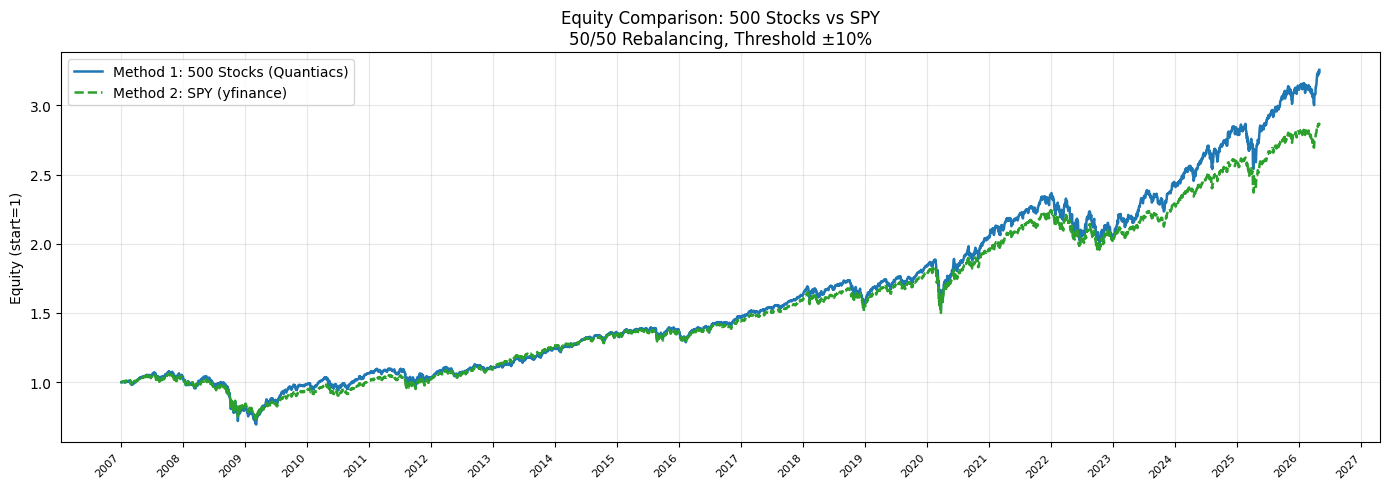

比較圖表已儲存至 results/comparison_s1_vs_s2.png


In [16]:
# ──────────────────────────────────────────────────────────────────
# 兩種方式並排比較
# ──────────────────────────────────────────────────────────────────

equity_s1 = stats_s1.to_pandas()['equity']
last_s1   = stats_s1.to_pandas().iloc[-1]

comparison = pd.DataFrame({
    '方式一（500支成分股）': [
        f'{last_s1["sharpe_ratio"]:.4f}',
        f'{last_s1["mean_return"]:.2%}',
        f'{last_s1["volatility"]:.2%}',
        f'{last_s1["max_drawdown"]:.2%}',
        f'{last_s1["avg_turnover"]:.2%}',
        f'{equity_s1.iloc[-1] / equity_s1.iloc[0] - 1:.2%}',
        f'{rebal_flags.sum()}',
    ],
    '方式二（SPY，yfinance）': [
        f'{sharpe_s2:.4f}',
        f'{mean_ret_s2:.2%}',
        f'{vol_s2:.2%}',
        f'{max_dd_s2:.2%}',
        f'{avg_turnover_s2:.2%}',
        f'{total_ret_s2:.2%}',
        f'{rebal_flags_s2.sum()}',
    ],
}, index=['Sharpe Ratio', 'Annual Return', 'Volatility',
          'Max Drawdown', 'Avg Turnover', 'Total Return', '再平衡次數'])

print('=== 兩種方式回測結果比較 ===')
display(comparison)

# 淨值曲線對比
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(equity_s1.index, equity_s1.values,
        color='#1f77b4', linewidth=1.8, label='Method 1: 500 Stocks (Quantiacs)')
ax.plot(equity_s2.index, equity_s2.values,
        color='#2ca02c', linewidth=1.8, linestyle='--', label='Method 2: SPY (yfinance)')

ax.set_title('Equity Comparison: 500 Stocks vs SPY\n50/50 Rebalancing, Threshold ±10%')
ax.set_ylabel('Equity (start=1)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('results/comparison_s1_vs_s2.png', dpi=150, bbox_inches='tight')
plt.show()
print('比較圖表已儲存至 results/comparison_s1_vs_s2.png')